# Rendering


In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcad.render import raymarch, render_marching_cubes, render_raymarched
from jaxcad.sdf.boolean import Difference, Intersection, Union
from jaxcad.sdf.primitives import Box, Capsule, RoundBox, Sphere, Torus
from jaxcad.sdf.transforms import Translate

## 1. Single sphere

The simplest scene — a unit sphere at the origin.  
`raymarch()` returns a plain NumPy array so you can display it however you like.

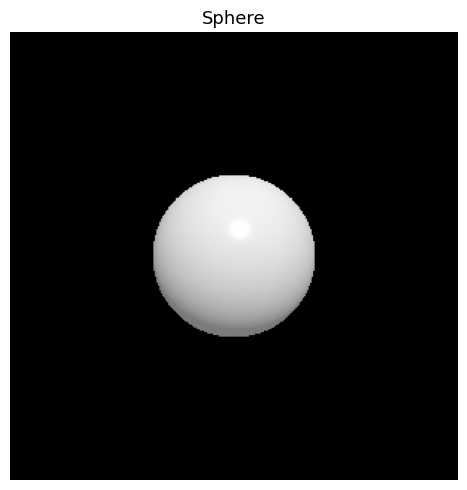

In [2]:
sphere = Sphere(radius=1.0)

image = raymarch(
    sphere,
    camera_pos=jnp.array([3.0, 2.0, 3.0]),
    look_at=jnp.array([0.0, 0.0, 0.0]),
    resolution=(300, 300),
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image, cmap="gray", vmin=0, vmax=1)
ax.axis("off")
ax.set_title("Sphere", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Primitives side-by-side

Each primitive rendered from the same camera position.

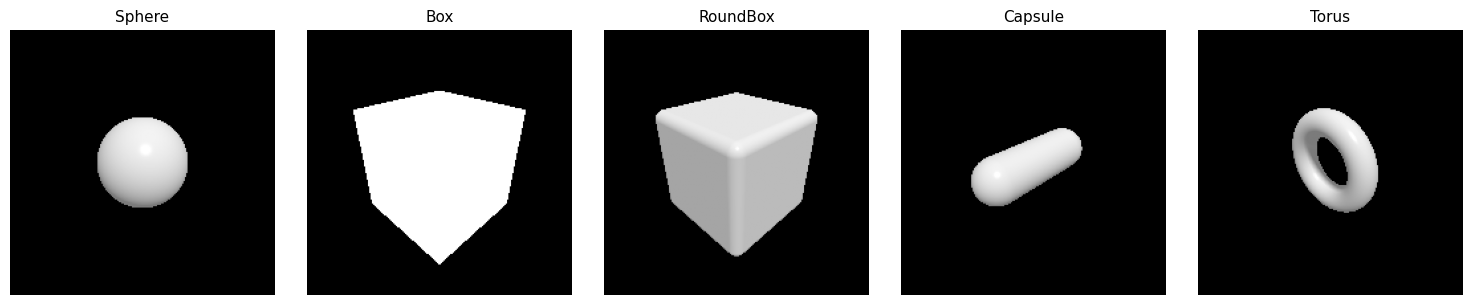

In [9]:
primitives = {
    "Sphere": Sphere(radius=1.0),
    "Box": Box(size=[1.2, 1.2, 1.2]),
    "RoundBox": RoundBox(size=[1.0, 1.0, 1.0], radius=0.2),
    "Capsule": Capsule(radius=0.5, height=1.0),
    "Torus": Torus(major_radius=0.9, minor_radius=0.3),
}

fig, axes = plt.subplots(1, len(primitives), figsize=(3 * len(primitives), 3))

cam = jnp.array([3.0, 2.5, 3.0])
for ax, (name, sdf) in zip(axes, primitives.items()):
    img = raymarch(sdf, camera_pos=cam, resolution=(200, 200))
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

## 3. Boolean operations

Union, intersection, and difference of two overlapping shapes.

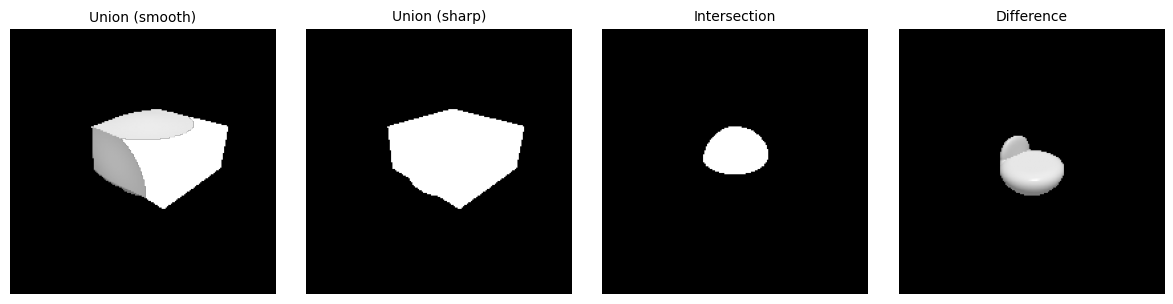

In [10]:
s = Sphere(radius=1.0)
b = Translate(Box(size=[1.2, 0.6, 1.2]), offset=jnp.array([0.6, 0.6, 0.0]))

scenes = {
    "Union (smooth)": Union((s, b), smoothness=0.2),
    "Union (sharp)": Union((s, b), smoothness=0.0),
    "Intersection": Intersection((s, b)),
    "Difference": Difference((s, b)),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
cam = jnp.array([4.0, 3.0, 4.0])

for ax, (name, scene) in zip(axes, scenes.items()):
    img = raymarch(scene, camera_pos=cam, resolution=(200, 200))
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

## 4. Shadow hardness

The `shadow_hardness` parameter controls shadow edge sharpness.  
Low values give soft penumbra; high values give hard edges.

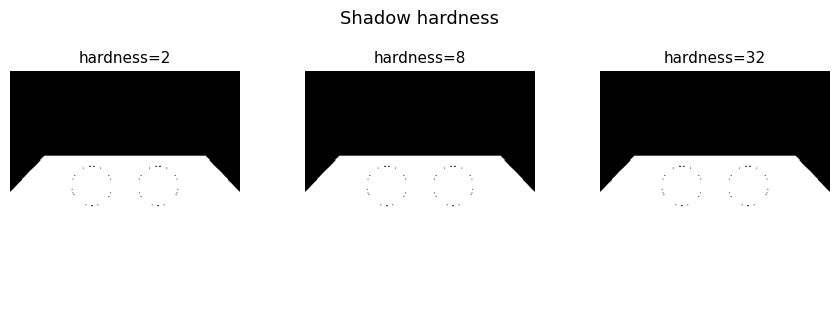

In [11]:
scene = Union(
    (
        Translate(Sphere(radius=0.6), offset=jnp.array([-1.0, 0.0, 0.0])),
        Translate(Sphere(radius=0.6), offset=jnp.array([1.0, 0.0, 0.0])),
        Translate(Box(size=[4.0, 0.1, 4.0]), offset=jnp.array([0.0, -0.7, 0.0])),
    ),
    smoothness=0.0,
)

hardness_values = [2.0, 8.0, 32.0]
labels = [f"hardness={h:.0f}" for h in hardness_values]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
cam = jnp.array([0.0, 3.0, 5.0])
light = jnp.array([2.0, 4.0, 2.0])

for ax, h, label in zip(axes, hardness_values, labels):
    img = raymarch(scene, camera_pos=cam, light_dir=light, resolution=(250, 250), shadow_hardness=h)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.suptitle("Shadow hardness", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Camera angles

The same scene from four different viewpoints.

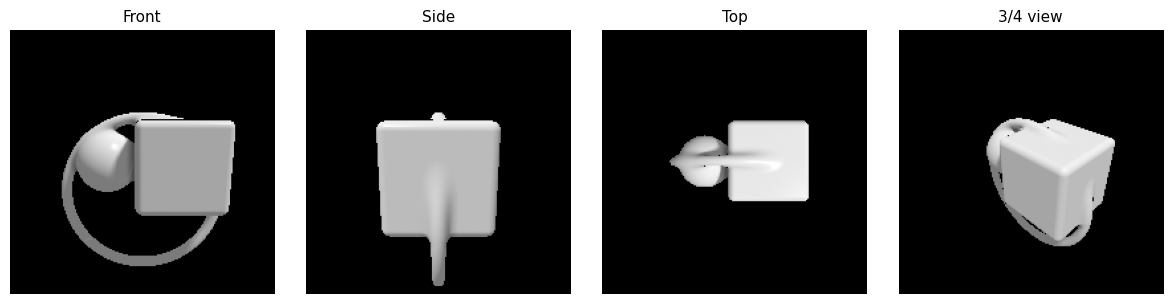

In [12]:
scene = Union(
    (
        Translate(Sphere(radius=0.7), offset=jnp.array([-0.8, 0.0, 0.0])),
        Translate(RoundBox(size=[0.8, 0.8, 0.8], radius=0.15), offset=jnp.array([0.8, 0.0, 0.0])),
        Translate(Torus(major_radius=1.8, minor_radius=0.12), offset=jnp.array([0.0, -0.8, 0.0])),
    ),
    smoothness=0.05,
)

cameras = [
    ("Front", jnp.array([0.0, 1.0, 5.0])),
    ("Side", jnp.array([5.0, 1.0, 0.0])),
    ("Top", jnp.array([0.0, 6.0, 0.1])),
    ("3/4 view", jnp.array([3.5, 3.0, 3.5])),
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (label, cam) in zip(axes, cameras):
    img = raymarch(scene, camera_pos=cam, resolution=(200, 200))
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

## 6. Complex scene

A more detailed scene rendered at higher resolution.

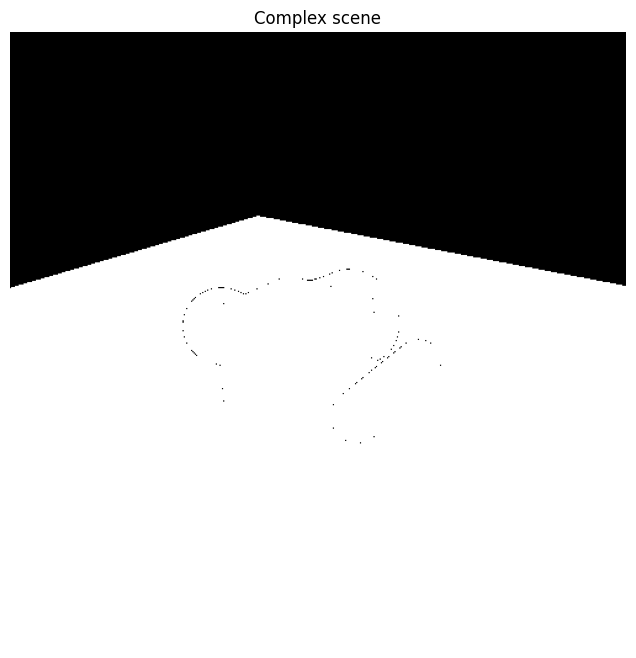

In [13]:
objects = Union(
    (
        Translate(Sphere(radius=0.6), offset=jnp.array([-1.5, 0.0, 0.0])),
        Translate(RoundBox([0.7, 0.7, 0.7], radius=0.1), offset=jnp.array([0.0, 0.0, 0.0])),
        Translate(Capsule(radius=0.3, height=0.8), offset=jnp.array([1.5, 0.0, 0.0])),
        Translate(Torus(major_radius=0.6, minor_radius=0.2), offset=jnp.array([0.0, 0.0, -1.5])),
        Translate(Sphere(radius=0.4), offset=jnp.array([-0.8, 0.0, -1.5])),
    ),
    smoothness=0.1,
)

# Ground plane approximated as a wide flat box
ground = Translate(Box(size=[8.0, 0.05, 8.0]), offset=jnp.array([0.0, -0.8, 0.0]))
scene = Union((objects, ground), smoothness=0.0)

render_raymarched(
    scene,
    camera_pos=jnp.array([4.0, 3.5, 5.0]),
    look_at=jnp.array([0.0, 0.0, -0.5]),
    light_dir=jnp.array([1.0, 2.0, 1.0]),
    resolution=(500, 500),
    shadow_hardness=6.0,
    title="Complex scene",
)
plt.show()

## 7. Raymarcher vs marching cubes

Both renderers on the same scene for comparison.

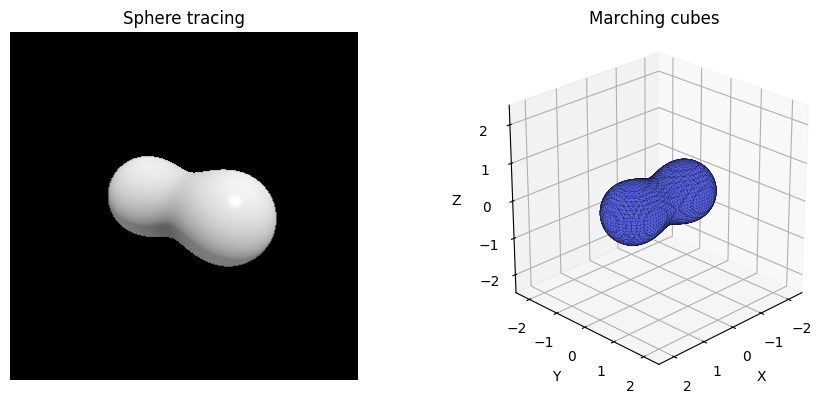

In [8]:
scene = Union(
    (
        Translate(Sphere(radius=0.8), offset=jnp.array([-0.9, 0.0, 0.0])),
        Translate(Sphere(radius=0.8), offset=jnp.array([0.9, 0.0, 0.0])),
    ),
    smoothness=0.3,
)

fig = plt.figure(figsize=(10, 4))

# Raymarcher
ax1 = fig.add_subplot(121)
render_raymarched(
    scene,
    camera_pos=jnp.array([3.0, 2.0, 4.0]),
    resolution=(350, 350),
    ax=ax1,
    title="Sphere tracing",
)

# Marching cubes
ax2 = fig.add_subplot(122, projection="3d")
render_marching_cubes(
    scene,
    bounds=(-2.5, -2.5, -2.5),
    size=(5, 5, 5),
    resolution=60,
    color="#5C69FF",
    alpha=0.85,
    ax=ax2,
    title="Marching cubes",
)
ax2.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()